## Homework

> Note: sometimes your answer doesn't match one of the options exactly. 
> That's fine. 
> Select the option that's closest to your solution.


### Dataset

In this homework, we will use the lead scoring dataset Bank Marketing dataset. Download it from [here](https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv).

Or you can do it with `wget`:

```bash
wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv
```

In this dataset our desired target for classification task will be `converted` variable - has the client signed up to the platform or not. 

### Data preparation

* Check if the missing values are presented in the features.
* If there are missing values:
    * For caterogiral features, replace them with 'NA'
    * For numerical features, replace with with 0.0 

### Question 1

What is the most frequent observation (mode) for the column `industry`?

- `NA`
- `technology`
- `healthcare`
- **`retail`**

In [873]:
# !wget https://raw.githubusercontent.com/alexeygrigorev/datasets/master/course_lead_scoring.csv

In [874]:
import pandas as pd

In [875]:
df = pd.read_csv('../data/course_lead_scoring.csv')
df

,lead_source,industry,number_of_courses_viewed,annual_income,employment_status,location,interaction_count,lead_score,converted
0,paid_ads,NaN,1,79450.0,unemployed,south_america,4,0.94,1
1,social_media,retail,1,46992.0,employed,south_america,1,0.80,0
2,events,healthcare,5,78796.0,unemployed,australia,3,0.69,1
3,paid_ads,retail,2,83843.0,NaN,australia,1,0.87,0
4,referral,education,3,85012.0,self_employed,europe,3,0.62,1
...,...,...,...,...,...,...,...,...,...
1457,referral,manufacturing,1,NaN,self_employed,north_america,4,0.53,1
1458,referral,technology,3,65259.0,student,europe,2,0.24,1
1459,paid_ads,technology,1,45688.0,student,north_america,3,0.02,1
1460,referral,NaN,5,71016.0,self_employed,north_america,0,0.25,1


In [876]:
df.isnull().sum()

lead_source                 128
industry                    134
number_of_courses_viewed      0
annual_income               181
employment_status           100
location                     63
interaction_count             0
lead_score                    0
converted                     0
dtype: int64

In [877]:
df.dtypes

lead_source                  object
industry                     object
number_of_courses_viewed      int64
annual_income               float64
employment_status            object
location                     object
interaction_count             int64
lead_score                  float64
converted                     int64
dtype: object

In [878]:
categorical = ['lead_source', 'industry', 'employment_status', 'location']
numerical = ['number_of_courses_viewed', 'annual_income', 'interaction_count', 'lead_score']

In [879]:
for col in categorical:
    df[col] = df[col].fillna('NA')

In [880]:
for col in numerical:
    df[col] = df[col].fillna(0.0)

In [881]:
df.isnull().sum()

lead_source                 0
industry                    0
number_of_courses_viewed    0
annual_income               0
employment_status           0
location                    0
interaction_count           0
lead_score                  0
converted                   0
dtype: int64

In [882]:
df['industry'].value_counts()

industry
retail           203
finance          200
other            198
healthcare       187
education        187
technology       179
manufacturing    174
NA               134
Name: count, dtype: int64

In [883]:
df['industry'].mode()[0]

'retail'

### Question 2

Create the [correlation matrix](https://www.google.com/search?q=correlation+matrix) for the numerical features of your dataset. 
In a correlation matrix, you compute the correlation coefficient between every pair of features.

What are the two features that have the biggest correlation?

- `interaction_count` and `lead_score`
- `number_of_courses_viewed` and `lead_score`
- `number_of_courses_viewed` and `interaction_count`
- **`annual_income` and `interaction_count`**

Only consider the pairs above when answering this question.

In [884]:
import seaborn as sns
import numpy as np

In [885]:
correlation_matrix = df[numerical].corr()
correlation_matrix

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,1.000000,0.009770,-0.023565,-0.004879
annual_income,0.009770,1.000000,0.027036,0.015610
interaction_count,-0.023565,0.027036,1.000000,0.009888
lead_score,-0.004879,0.015610,0.009888,1.000000


<Axes: >

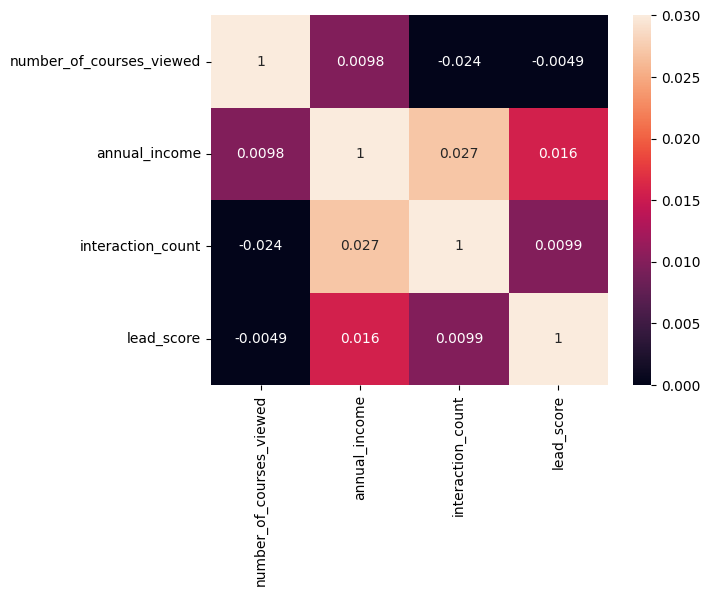

In [886]:
sns.heatmap(correlation_matrix, annot=True, vmin=0, vmax=0.03)

In [887]:
mask = np.triu(np.ones_like(correlation_matrix), k=1)
mask

array([[0., 1., 1., 1.],
       [0., 0., 1., 1.],
       [0., 0., 0., 1.],
       [0., 0., 0., 0.]])

In [888]:
correlation_matrix_masked = correlation_matrix * mask
correlation_matrix_masked

,number_of_courses_viewed,annual_income,interaction_count,lead_score
number_of_courses_viewed,0.0,0.00977,-0.023565,-0.004879
annual_income,0.0,0.00000,0.027036,0.015610
interaction_count,-0.0,0.00000,0.000000,0.009888
lead_score,-0.0,0.00000,0.000000,0.000000


In [889]:
max_corr = correlation_matrix_masked.max().max()
max_corr

np.float64(0.027036472404814396)

In [890]:
max_idx = np.where(correlation_matrix_masked == max_corr)
max_idx

(array([1]), array([2]))

In [891]:
feature1 = numerical[max_idx[0][0]]
feature1

'annual_income'

In [892]:
feature2 = numerical[max_idx[1][0]]
feature2

'interaction_count'

In [893]:
print(f"\nHighest correlation ({max_corr:.3f}) is between: {feature1} and {feature2}")


Highest correlation (0.027) is between: annual_income and interaction_count


### Split the data

* Split your data in train/val/test sets with 60%/20%/20% distribution.
* Use Scikit-Learn for that (the `train_test_split` function) and set the seed to `42`.
* Make sure that the target value `y` is not in your dataframe.

In [894]:
from sklearn.model_selection import train_test_split

In [895]:
df_temp, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [896]:
len(df_temp), len(df_test)

(1169, 293)

In [897]:
df_train, df_val = train_test_split(df_temp, test_size=0.25, random_state=42)

In [898]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [899]:
len(df_train), len(df_val), len(df_test)

(876, 293, 293)

In [900]:
y_train = df_train.converted.values
y_val = df_val.converted.values
y_test = df_test.converted.values

In [901]:
len(y_train), len(y_val), len(y_test)

(876, 293, 293)

In [902]:
del df_train['converted']
del df_val['converted']
del df_test['converted']

### Question 3

* Calculate the mutual information score between `y` and other categorical variables in the dataset. Use the training set only.
* Round the scores to 2 decimals using `round(score, 2)`.

Which of these variables has the biggest mutual information score?
  
- `industry`
- `location`
- **`lead_source`**
- `employment_status`

In [903]:
from sklearn.metrics import mutual_info_score

In [904]:
mi_scores = {}

for col in categorical:
    mi_score = mutual_info_score(df_train[col], y_train)
    mi_scores[col] = round(mi_score, 2)
    print(f"Mutula score for {col} = {mi_scores[col]}")

Mutula score for lead_source = 0.04
Mutula score for industry = 0.01
Mutula score for employment_status = 0.01
Mutula score for location = 0.0


In [905]:
mi_scores

{'lead_source': 0.04,
 'industry': 0.01,
 'employment_status': 0.01,
 'location': 0.0}

In [906]:
mi_scores_sorted = dict(sorted(mi_scores.items(), key=lambda x: x[1], reverse=True))
mi_scores_sorted

{'lead_source': 0.04,
 'industry': 0.01,
 'employment_status': 0.01,
 'location': 0.0}

In [907]:
for feature, score in mi_scores_sorted.items():
    print(f"{feature}: {score}")

lead_source: 0.04
industry: 0.01
employment_status: 0.01
location: 0.0


### Question 4

* Now let's train a logistic regression.
* Remember that we have several categorical variables in the dataset. Include them using one-hot encoding.
* Fit the model on the training dataset.
    - To make sure the results are reproducible across different versions of Scikit-Learn, fit the model with these parameters:
    - `model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)`
* Calculate the accuracy on the validation dataset and round it to 2 decimal digits.

What accuracy did you get?

- 0.64
- 0.74
- 0.84
- 0.94

In [908]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [909]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')
train_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'retail',
 'employment_status': 'student',
 'location': 'middle_east',
 'number_of_courses_viewed': 0,
 'annual_income': 58472.0,
 'interaction_count': 5,
 'lead_score': 0.03}

In [910]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')
val_dicts[0]

{'lead_source': 'paid_ads',
 'industry': 'healthcare',
 'employment_status': 'unemployed',
 'location': 'europe',
 'number_of_courses_viewed': 3,
 'annual_income': 52220.0,
 'interaction_count': 1,
 'lead_score': 0.07}

In [911]:
dv = DictVectorizer(sparse=False)
X_train = dv.fit_transform(train_dicts)
X_train[0]

array([5.8472e+04, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 5.0000e+00,
       3.0000e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 1.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00])

In [912]:
X_val = dv.transform(val_dicts)
X_val[0]

array([5.222e+04, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 1.000e+00, 7.000e-02, 0.000e+00, 0.000e+00,
       0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       3.000e+00])

In [913]:
model = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [914]:
y_pred = model.predict(X_val)

In [915]:
accuracy = round(accuracy_score(y_val, y_pred), 2)
print(f'Validation accuracy: {accuracy}')

Validation accuracy: 0.7


### Question 5 

* Let's find the least useful feature using the *feature elimination* technique.
* Train a model using the same features and parameters as in Q4 (without rounding).
* Now exclude each feature from this set and train a model without it. Record the accuracy for each model.
* For each feature, calculate the difference between the original accuracy and the accuracy without the feature. 

Which of following feature has the smallest difference?

- `'industry'`
- `'employment_status'`
- **`'lead_score'`**

> **Note**: The difference doesn't have to be positive.

In [916]:
original_accuracy = accuracy_score(y_val, y_pred)
original_accuracy

0.6996587030716723

In [917]:
features_to_check = ['industry', 'employment_status', 'lead_score']

In [918]:
accuracy_differences = {}

for feature in features_to_check:
    feature_list = categorical + numerical
    feature_list.remove(feature)

    train_dicts_subset = df_train[feature_list].to_dict(orient='records')
    val_dicts_subset = df_val[feature_list].to_dict(orient='records')

    dv_subset = DictVectorizer(sparse=False)
    X_train_subset = dv_subset.fit_transform(train_dicts_subset)
    X_val_subset = dv_subset.transform(val_dicts_subset) 

    model_subset = LogisticRegression(solver='liblinear', C=1.0, max_iter=1000, random_state=42)
    model_subset.fit(X_train_subset, y_train)
    y_pred_subset = model_subset.predict(X_val_subset)

    accuracy_subset = accuracy_score(y_val, y_pred_subset)
    difference = original_accuracy - accuracy_subset
    accuracy_differences[feature] = difference
    print(f"Removed {feature}: new accuracy = {accuracy_subset:.4f}, difference = {difference:.4f}")

Removed industry: new accuracy = 0.6997, difference = 0.0000
Removed employment_status: new accuracy = 0.6962, difference = 0.0034
Removed lead_score: new accuracy = 0.7065, difference = -0.0068


In [919]:
print("\nFeatures sorted by absolute difference:")
for feature, diff in sorted(accuracy_differences.items(), key=lambda x: abs(x[1])):
    print(f"{feature}: {diff:.4f}")


Features sorted by absolute difference:
industry: 0.0000
employment_status: 0.0034
lead_score: -0.0068


### Question 6

* Now let's train a regularized logistic regression.
* Let's try the following values of the parameter `C`: `[0.01, 0.1, 1, 10, 100]`.
* Train models using all the features as in Q4.
* Calculate the accuracy on the validation dataset and round it to 3 decimal digits.

Which of these `C` leads to the best accuracy on the validation set?

- **0.01**
- 0.1
- 1
- 10
- 100

> **Note**: If there are multiple options, select the smallest `C`.

In [920]:
c_values = [0.01, 0.1, 1, 10, 100]

In [921]:
accuracies = {}

for c in c_values:
    # Initialize and train model with current C
    model = LogisticRegression(solver='liblinear', C=c, max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    
    # Make predictions and calculate accuracy
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    accuracies[c] = round(accuracy, 3)
    
    print(f"C={c}: accuracy={accuracies[c]:.3f}")

C=0.01: accuracy=0.700
C=0.1: accuracy=0.700
C=1: accuracy=0.700
C=10: accuracy=0.700
C=100: accuracy=0.700


In [922]:
best_c = min([c for c in c_values if accuracies[c] == max(accuracies.values())])
print(f"\nBest accuracy {accuracies[best_c]} achieved with C={best_c}")


Best accuracy 0.7 achieved with C=0.01
